<a href="https://colab.research.google.com/github/PauSerranoHerraiz/S7-01-Pau-Serrano/blob/main/S9_01_Pau_Serrano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: MacBook-Pro-de-Pau.local
Python: /Library/Frameworks/Python.framework/Versions/3.14/bin/python3
Usuari: pauserranoherraiz


# <font color ="green"> Nivell 1 - Visualització analítica guiada en Python </font>

## <font color="pink"> Exercici 1: Preguntes analítiques directes (sense integracions complexes) </font>
🌍 Context: Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

Aspectes a revisar i analitzar:

» Identificar quina informació és necessàriaQuin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

Preguntes analítiques: (només utilitzant la taula de transaccions) :

1. Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

Selecciona la columna temporal adequada.

Defineix el nivell temporal d'anàlisi.

Compta el nombre de registres per període temporal.

Ordena els resultats cronològicament.

Visualitza l'evolució amb un gràfic de línies amb pandas.

2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.


Identifica la columna que representa el usuari.

Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.

Ordena els usuaris de major a menor volum de facturació.

Selecciona els N usuaris principals (per exemple, els 15 primers).

Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.


Crea una nova columna amb l'hora del dia a partir del timestamp.
Utilitza un violinplot de seaborn per analitzar la distribució dels imports.

Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.

Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

4. Quins dies de la setmana es concentra més activitat de venda?

👉 Per a cada pregunta:

Construeix una visualització senzilla en Python sense utilitzar IA.

Interpreta breument el resultat obtingut.

Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

In [3]:
%pip install matplotlib
%pip install seaborn
%pip install mysql-connector-python
%pip install sqlalchemy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import sqlalchemy as db

# Establim la conexió amb la BBDD

conexion = mysql.connector.connect(
    host='localhost',
    user='root',
    password='123456',
    database='transactions'
)

cursor = conexion.cursor()

df_transaction = pd.read_sql("SELECT * FROM transaction", conexion)
print("Columnes disponibles al df_transaction:", df_transaction.columns.tolist())

display(df_transaction.head())

df_transaction.sort_values('timestamp', ascending=False)

# Assegurem tipu datetime a Pandas desde el TIMESTAMP de MySQL
df_transaction['timestamp'] = pd.to_datetime(df_transaction['timestamp'])

# Extraiem el component de la hora (0-23)
df_transaction['hora_dia'] = df_transaction['timestamp'].dt.hour

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/var/folders/bq/btk_8tlx60sbjvf097r5qb000000gn/T/ipykernel_1460/1033294877.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transaction = pd.read_sql("SELECT * FROM transaction", conexion)


Columnes disponibles al df_transaction: ['id', 'credit_card_id', 'company_id', 'user_id', 'lat', 'longitude', 'timestamp', 'amount', 'declined']


,id,credit_card_id,company_id,user_id,lat,longitude,timestamp,amount,declined
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,4713,46.1999,1.43554,2024-08-28 07:16:46,395.43,0
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,438,41.5972,12.22180,2016-12-21 20:07:18,155.63,0
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2118,29.7573,-95.37960,2020-07-14 15:37:45,326.01,0
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2115,53.5489,-113.50300,2017-09-04 19:44:53,161.60,0
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,3025,52.2084,5.69081,2017-01-05 18:19:25,148.91,0


### <font color = "orange">1. Evolució del nombre de transaccions al llarg del temps

In [4]:
# Selecciona la columna temporal adequada i defineix el nivell temporal d'anàlisi
df_transaction['date_only'] = df_transaction['timestamp'].dt.date

# Compta el nombre de registres per període temporal
transactions_per_day = df_transaction.groupby('date_only').size()

# Ordena els resultats cronològicament
transactions_per_day = transactions_per_day.sort_index()

display(transactions_per_day.head())
display(transactions_per_day.tail())

date_only
2015-01-01    28
2015-01-02    16
2015-01-03    24
2015-01-04    27
2015-01-05    27
dtype: int64

date_only
2024-12-27    30
2024-12-28    27
2024-12-29    27
2024-12-30    30
2024-12-31    30
dtype: int64

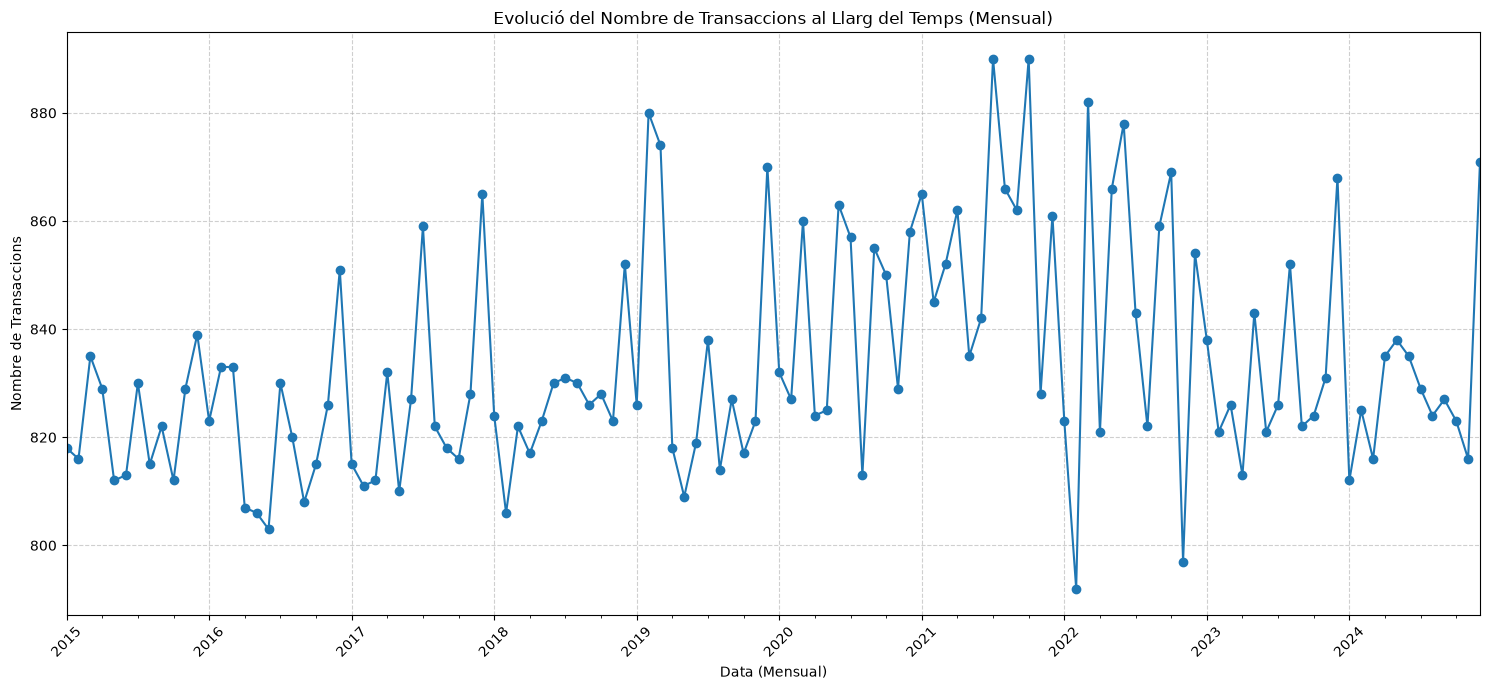

In [5]:
# Visualitza l'evolució amb un gràfic de línies amb pandas
plt.figure(figsize=(15, 7))

transactions_per_day.index = pd.to_datetime(transactions_per_day.index)
transactions_per_month = transactions_per_day.resample('ME').sum()

transactions_per_month.plot(kind='line', marker='o', linestyle='-')

plt.title('Evolució del Nombre de Transaccions al Llarg del Temps (Mensual)')
plt.xlabel('Data (Mensual)')
plt.ylabel('Nombre de Transaccions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### <font color="orange">Interpretació del resultat:

Aquest gràfic de línies mostra el nombre de transaccions mensuals. Podem observar tendències, com ara mesos amb més activitat o possibles períodes de menys transaccions. Els pics o valls en la línia poden indicar esdeveniments específics (promocions, festius, etc.).

---

### <font color = "orange">2. Usuaris amb més volum de facturació:

In [6]:
# Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna 'amount'
transaccions_usuari = df_transaction.groupby('user_id')['amount'].sum().reset_index()

# Ordena els usuaris de major a menor volum de facturació
transaccions_usuari_ordenat = transaccions_usuari.sort_values(by='amount', ascending=False)

# Selecciona els N usuaris principals (per exemple, els 15 primers)
top_users = transaccions_usuari_ordenat.head(15)

display(top_users)

,user_id,amount
288,289,41486.54
317,318,40348.50
454,455,34491.27
416,417,32016.11
184,185,30333.03
284,285,29249.51
192,193,25485.05
453,454,24353.91
348,349,23504.47
316,317,18991.45


/var/folders/bq/btk_8tlx60sbjvf097r5qb000000gn/T/ipykernel_1460/2874605939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='user_id', y='amount', data=top_users, palette='magma_r')


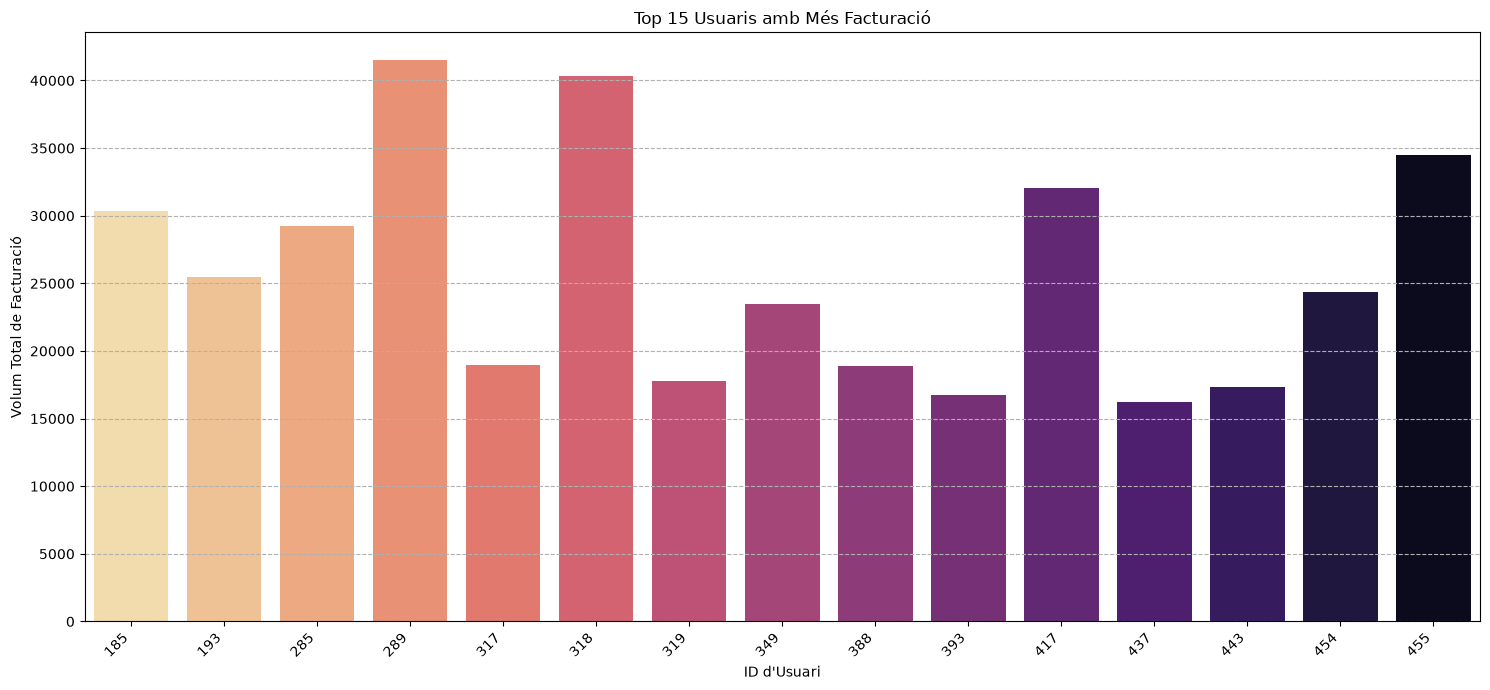

In [7]:
# Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn
plt.figure(figsize=(15, 7))
sns.barplot(x='user_id', y='amount', data=top_users, palette='magma_r')
plt.title('Top 15 Usuaris amb Més Facturació')
plt.xlabel('ID d\'Usuari')
plt.ylabel('Volum Total de Facturació')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()

#### <font color="orange">Interpretació del resultat:

Aquest gràfic de barres mostra els 15 usuaris que han generat el major volum total de facturació. Podem observar que hi ha una clara diferència entre el primer usuari i la resta, indicant que pocs usuaris contribueixen significativament al volum total de vendes. Això podria ser útil per a campanyes de fidelització o per identificar usuaris clau.

### <font color = "orange">3. Diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades:</font>

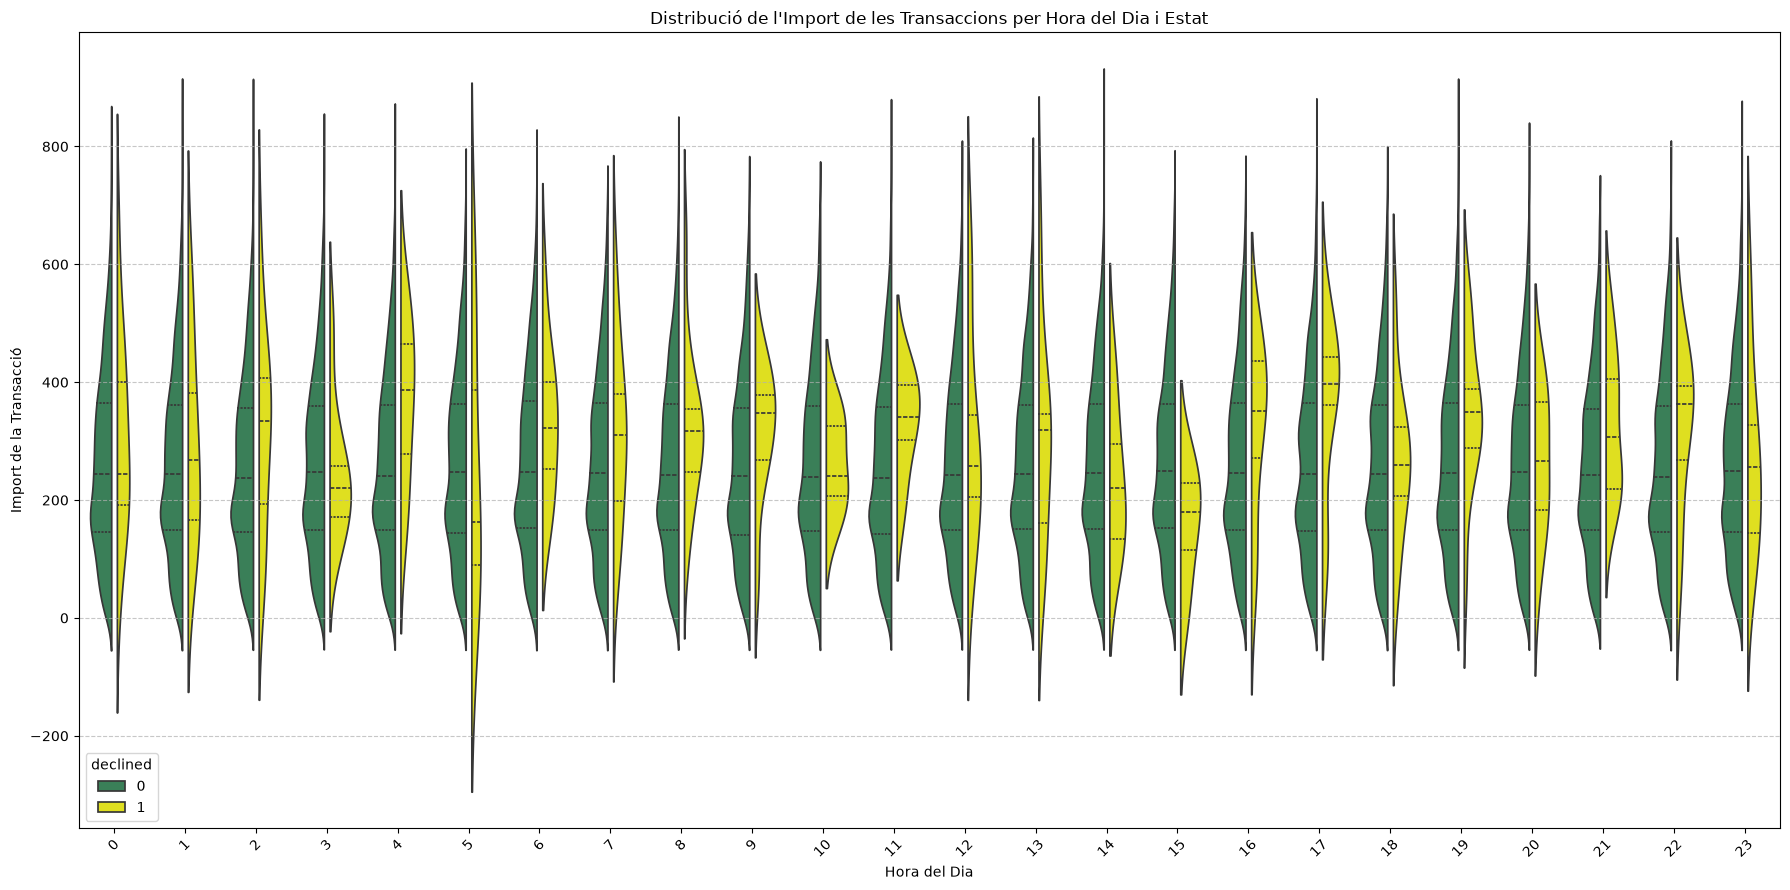

In [8]:
# Crea una nova columna amb l'hora del dia a partir del timestamp
df_transaction['hora_dia'] = df_transaction['timestamp'].dt.hour

# Utilitza un violinplot de seaborn per analitzar la distribució dels imports
plt.figure(figsize=(18, 9))

# Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
# Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.
sns.violinplot(x='hora_dia', y='amount', hue='declined', data=df_transaction, split=True, gap=.2, inner='quartile', palette={0: 'seagreen', 1: 'yellow'})

plt.title('Distribució de l\'Import de les Transaccions per Hora del Dia i Estat')
plt.xlabel('Hora del Dia')
plt.ylabel('Import de la Transacció')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### <font color="orange">Interpretació del resultat:

Aquest <font color = "pink">violinplot</font> mostra la distribució dels imports de les transaccions per cada hora del dia, distingint entre transaccions acceptades (0) i rebutjades (1). La forma del violí indica la densitat de la distribució, mentre que les línies internes representen els quartils i la mediana. Podem observar si hi ha hores del dia on la distribució dels imports és significativament diferent entre transaccions acceptades i rebutjades, o si hi ha pics d'imports més alts o més baixos en certes franges.

,day_of_week_num,day_of_week_name,count
0,0,Dilluns,14122
1,1,Dimarts,14176
2,2,Dimecres,14272
3,3,Dijous,14516
4,4,Divendres,14272
5,5,Dissabte,14353
6,6,Diumenge,14289


/var/folders/bq/btk_8tlx60sbjvf097r5qb000000gn/T/ipykernel_1460/3463033691.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week_name', y='count', data=transactions_by_day, palette='magma_r')


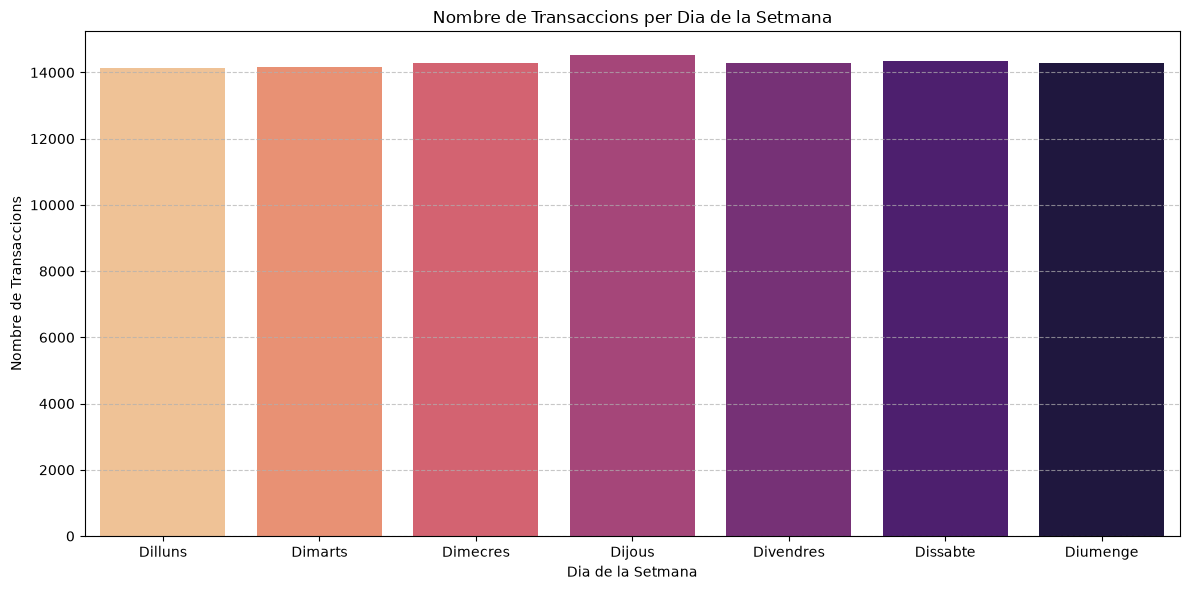

In [9]:
# Quins dies de la setmana es concentra més activitat de venda?

# Extreu el dia de la setmana (0=Dilluns, 6=Diumenge)
df_transaction['day_of_week_num'] = df_transaction['timestamp'].dt.dayofweek
df_transaction['day_of_week_name'] = df_transaction['timestamp'].dt.day_name(locale='ca_ES')

# Compta el nombre de transaccions per dia de la setmana
transactions_by_day = df_transaction.groupby(['day_of_week_num', 'day_of_week_name']).size().reset_index(name='count')

# Ordena els dies de la setmana cronològicament
transactions_by_day = transactions_by_day.sort_values('day_of_week_num')

display(transactions_by_day)

# Representa el resultat mitjançant un gràfic de barres
plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week_name', y='count', data=transactions_by_day, palette='magma_r')
plt.title('Nombre de Transaccions per Dia de la Setmana')
plt.xlabel('Dia de la Setmana')
plt.ylabel('Nombre de Transaccions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### <font color="orange">Interpretació del resultat:

Aquest gràfic de barres ens mostra l'activitat de bvenda per dia de la setmana. Com podem veure, si que sembla que el dia amb més vendes és el dijous, però la diferència amb la resta de dies (caps de setmana inclòs) no és significativa. El número de vendes es manté bastant estable al llarh de tota la setmana (sempre entre les 1100 i les 1500 transaccions).

## <font color ="pink"> Exercici 2: Preguntes analítiques complexes (amb guia)

🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

Preguntes analítiques (amb guia general)

» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

» Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

» Anàlisi de concentració i variabilitat (tria UNA opció)

Opció A – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

Opció B – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

👉 Per a cada pregunta:

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.



/var/folders/bq/btk_8tlx60sbjvf097r5qb000000gn/T/ipykernel_1460/1441584142.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_company = pd.read_sql("SELECT * FROM company", conexion)


,company_id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings


,id,credit_card_id,company_id,user_id,lat,longitude,timestamp,amount,declined,hora_dia,date_only,day_of_week_num,day_of_week_name,company_name,phone,email,country,website
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,4713,46.1999,1.43554,2024-08-28 07:16:46,395.43,0,7,2024-08-28,2,Dimecres,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,438,41.5972,12.22180,2016-12-21 20:07:18,155.63,0,20,2016-12-21,2,Dimecres,Non Justo Corp.,09 30 54 14 44,urna.ut.tincidunt@yahoo.edu,Sweden,https://baidu.com/en-us
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2118,29.7573,-95.37960,2020-07-14 15:37:45,326.01,0,15,2020-07-14,1,Dimarts,Neque Tellus Imperdiet Corp.,09 15 42 22 11,vestibulum.ante.ipsum@aol.edu,Ireland,https://whatsapp.com/sub/cars
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2115,53.5489,-113.50300,2017-09-04 19:44:53,161.60,0,19,2017-09-04,0,Dilluns,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,3025,52.2084,5.69081,2017-01-05 18:19:25,148.91,0,18,2017-01-05,3,Dijous,Mus Aenean Eget Foundation,06 25 15 52 43,mi.duis@hotmail.net,Sweden,https://instagram.com/group/9


,country,amount,percentage,cumulative_percentage
12,Sweden,4251072.86,16.412438,16.412438
8,Netherlands,3890755.90,15.021336,31.433774
13,United Kingdom,3537120.34,13.656028,45.089802
7,Italy,3530071.81,13.628815,58.718617
5,Germany,3466842.93,13.384703,72.103320
4,France,1221902.17,4.717490,76.820810
14,United States,1069450.71,4.128909,80.949719
1,Belgium,922131.39,3.560142,84.509861
10,Norway,785907.27,3.034212,87.544073
6,Ireland,693054.42,2.675728,90.219801


/var/folders/bq/btk_8tlx60sbjvf097r5qb000000gn/T/ipykernel_1460/1441584142.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='amount', data=facturacio_per_pais_ordenat, palette='viridis', ax=ax1)


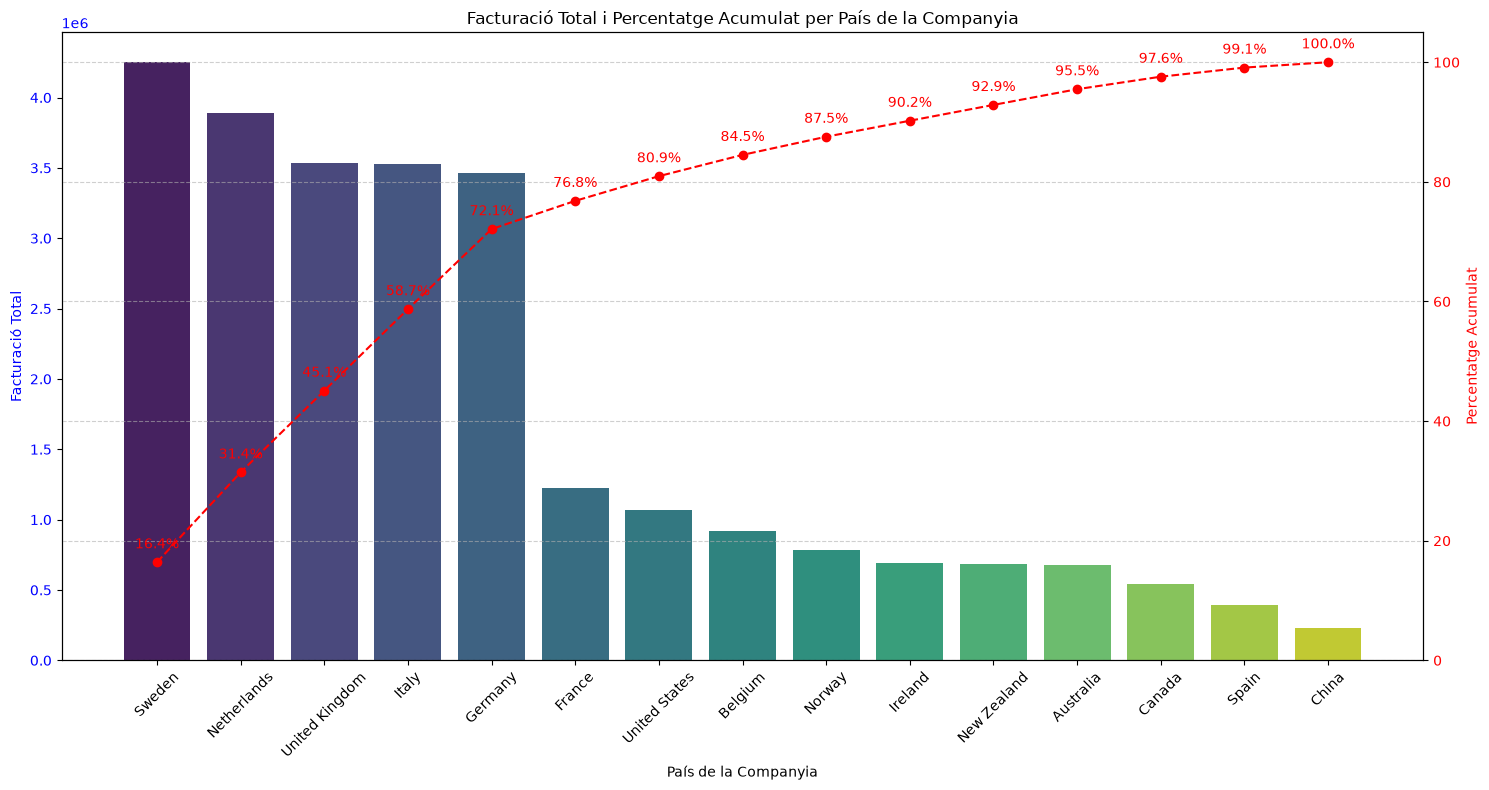

In [12]:
# Depenem excessivament d'un nombre reduït de països de companyies venedores?

# 1. Combinar la informació de transaccions amb la de companyies.
# Assumint que hi ha una taula 'company' a la base de dades amb 'company_id' i 'country'.

df_company = pd.read_sql("SELECT * FROM company", conexion)

# Renombrar la columna 'id' a 'company_id' en df_company per a que coincideixi amb df_transaction
df_company = df_company.rename(columns={'id': 'company_id'})
display(df_company.head())

df_merged = pd.merge(df_transaction, df_company, on='company_id', how='left')
display(df_merged.head())

# 2. Agrupar la facturació per país.
# 3. Calcular la facturació total generada per cada país.
facturacio_per_pais = df_merged.groupby('country')['amount'].sum().reset_index()

# 4. Ordenar els països de major a menor facturació.
facturacio_per_pais_ordenat = facturacio_per_pais.sort_values(by='amount', ascending=False)

# 5. Calcular el percentatge acumulat sobre el total.
facturacio_per_pais_ordenat['percentage'] = (facturacio_per_pais_ordenat['amount'] / facturacio_per_pais_ordenat['amount'].sum()) * 100
facturacio_per_pais_ordenat['cumulative_percentage'] = facturacio_per_pais_ordenat['percentage'].cumsum()

display(facturacio_per_pais_ordenat)

# 6. Visualitzar
fig, ax1 = plt.subplots(figsize=(15, 8))

sns.barplot(x='country', y='amount', data=facturacio_per_pais_ordenat, palette='viridis', ax=ax1)
ax1.set_title('Facturació Total i Percentatge Acumulat per País de la Companyia')
ax1.set_xlabel('País de la Companyia')
ax1.set_ylabel('Facturació Total', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(facturacio_per_pais_ordenat['country'], facturacio_per_pais_ordenat['cumulative_percentage'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Percentatge Acumulat', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

# Afegim etiquetes de percentatge a la linea del gràfic
for index, row in facturacio_per_pais_ordenat.iterrows():
    ax2.annotate(f'{row["cumulative_percentage"]:,.1f}%', (row['country'], row['cumulative_percentage']), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### <font color="orange">Interpretació del resultat:

Aquest gràfic combinat mostra la contribució de cada país a la facturació total.
La barra blava representa la facturació individual de cada país, ordenada de major a menor.
La línia vermella representa el percentatge acumulat. Si la línia creix ràpidament i arriba a un alt percentatge amb pocs països, indica una alta dependència. Per contra, si la línia és més plana, hi ha una distribució més equitativa i menys dependència d'un nombre reduït de països.

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,
1,208460.24,212357.82,209339.50,214646.54,210813.99,219397.63,232197.63,212873.78,218300.84,213306.61
2,211179.56,214708.37,215198.48,209918.88,222423.06,211273.68,219685.97,202945.83,214480.16,214826.07
3,221488.19,215368.86,208608.27,207377.32,243592.36,227262.89,220554.92,238293.06,212086.80,215896.22
4,214675.51,210019.54,218995.78,205562.05,212679.25,213422.08,227276.44,209160.91,214159.74,212718.45
5,215691.13,208713.77,204784.10,210126.23,208853.84,216073.84,206925.66,236573.86,225828.47,218842.78
6,207759.31,208534.96,216287.92,217047.48,220443.02,212762.98,211362.56,233213.16,210788.42,222297.43
7,218137.92,213505.12,218788.44,208823.33,211037.50,217751.47,227301.53,211532.08,215904.46,208427.29
8,214170.06,212853.75,209566.97,207536.16,215470.42,210762.54,214414.67,220744.50,214257.04,214924.40
9,204305.09,217441.50,211802.81,214016.87,210429.63,231158.60,222361.90,228802.26,213400.04,212523.25


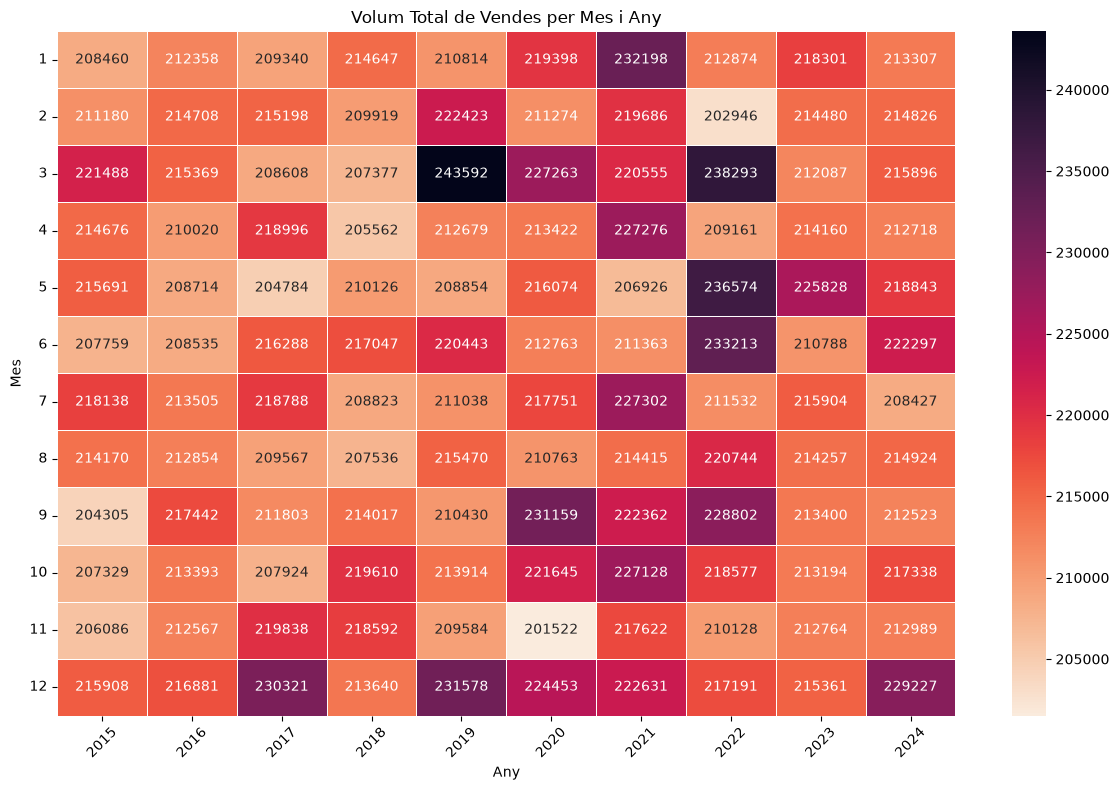

In [22]:
df_transaction['year'] = df_transaction['timestamp'].dt.year
df_transaction['month'] = df_transaction['timestamp'].dt.month

vendes_per_mes_any = df_transaction.groupby(['year', 'month'])['amount'].sum().reset_index()

pivot_vendes = vendes_per_mes_any.pivot(index='month', columns='year', values='amount')

display(pivot_vendes)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_vendes, cmap='rocket_r', fmt=".0f", linewidths=.5, annot=True)
plt.title('Volum Total de Vendes per Mes i Any')
plt.xlabel('Any')
plt.ylabel('Mes')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### <font color="orange">Interpretació del resultat:

En aquest mapa de calor distribuït per mesos i anys podem veure, de forma fàcil i clara, quins mesos de cada any han tingut més i menys ingressos.
No s'observa una estacionalitat clara ja que, dins dels mateixos anys, la facturació es manté bastant estable durant tots els mesos, sense cap pic ni devallada importants en cuant a facturació.

,user_id,data_ultima_compra,dies_desde_ultima_compra
0,1,2024-11-15 14:48:20,46
1,2,2024-04-20 06:41:27,255
2,3,2024-02-22 03:31:36,313
3,4,2024-12-29 11:47:48,2
4,5,2024-05-02 21:11:06,243
...,...,...,...
4995,4996,2023-06-22 13:59:16,558
4996,4997,2024-10-05 10:01:11,87
4997,4998,2024-12-09 19:48:11,22
4998,4999,2024-08-04 04:51:44,149


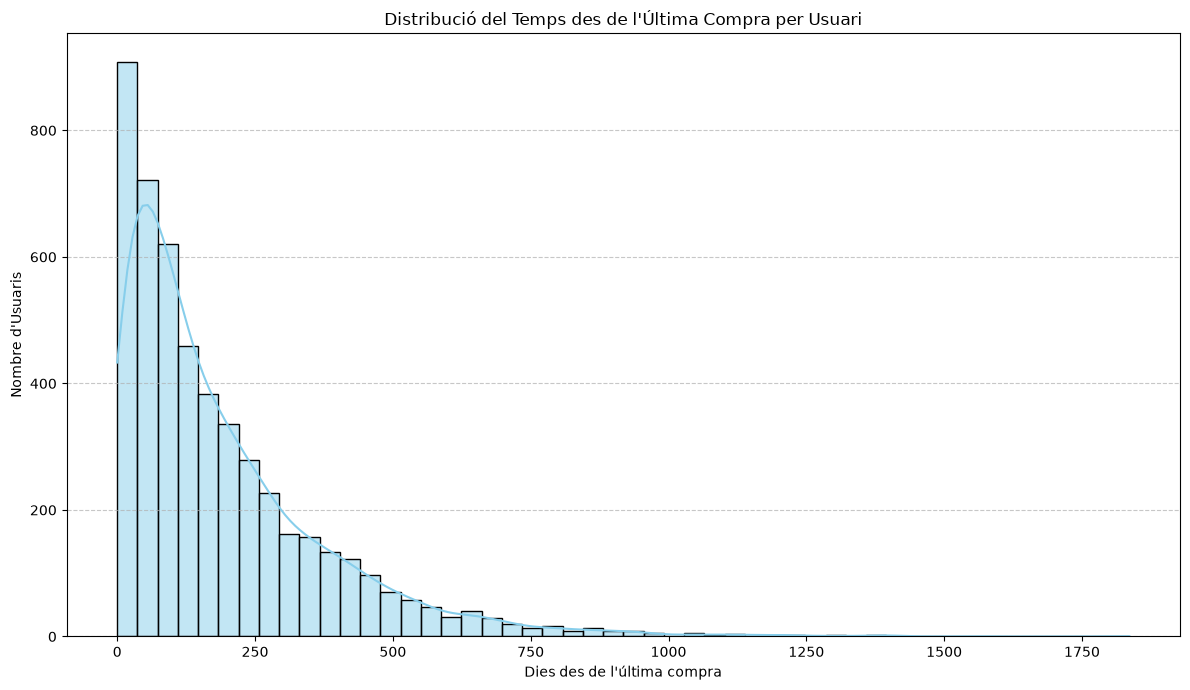

In [26]:
# Identificar l'última compra per usuari.
ultima_compra = df_transaction.groupby('user_id')['timestamp'].max().reset_index()
ultima_compra.rename(columns={'timestamp': 'data_ultima_compra'}, inplace=True)

# Calcular el temps des de l'última compra.
# Utilitzarem la data màxima del dataset com a 'avui' per calcular-ho.
current_date = df_transaction['timestamp'].max()
ultima_compra['dies_desde_ultima_compra'] = (current_date - ultima_compra['data_ultima_compra']).dt.days

display(ultima_compra)

# Visualitzar la distribució del temps des de l'última compra.
plt.figure(figsize=(12, 7))
sns.histplot(ultima_compra['dies_desde_ultima_compra'], bins=50, kde=True, color='skyblue')
plt.title('Distribució del Temps des de l\'Última Compra per Usuari')
plt.xlabel('Dies des de l\'última compra')
plt.ylabel('Nombre d\'Usuaris')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### <font color="orange">Interpretació del resultat:

En aquest gràfic podem veure la relació entre número d'usuaris i els dies transcorreguts desde la seva ultima compra.
La bona notícia per al client, es que el volum d'usuaris es concentra, principalment, en la part amb menys dies transcorreguts. a mesura que sumem dies, disminueix el numero d'usuaris.

Per això, poem dir que els usuaris compren amb certa asiduitat i que acostumen a repetir en un marge de temps relativament curt.

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
time_band,,,,,,,,,,
Matinada (00h-05h),634217.00,637156.46,629540.64,649588.10,634341.30,669367.83,662185.11,665762.40,664766.21,641959.64
Matí (06h-11h),631480.53,646776.32,638536.96,616194.09,665608.61,648667.63,670951.45,636430.72,645600.52,641414.76
Migdia (12h-17h),641201.28,658150.89,671531.26,641555.63,664017.43,632334.31,672333.14,661868.27,648992.82,658733.94
Nit (18h-23h),638291.26,614261.05,631846.36,639559.01,646851.09,657116.82,643993.22,675974.25,621165.03,651207.83


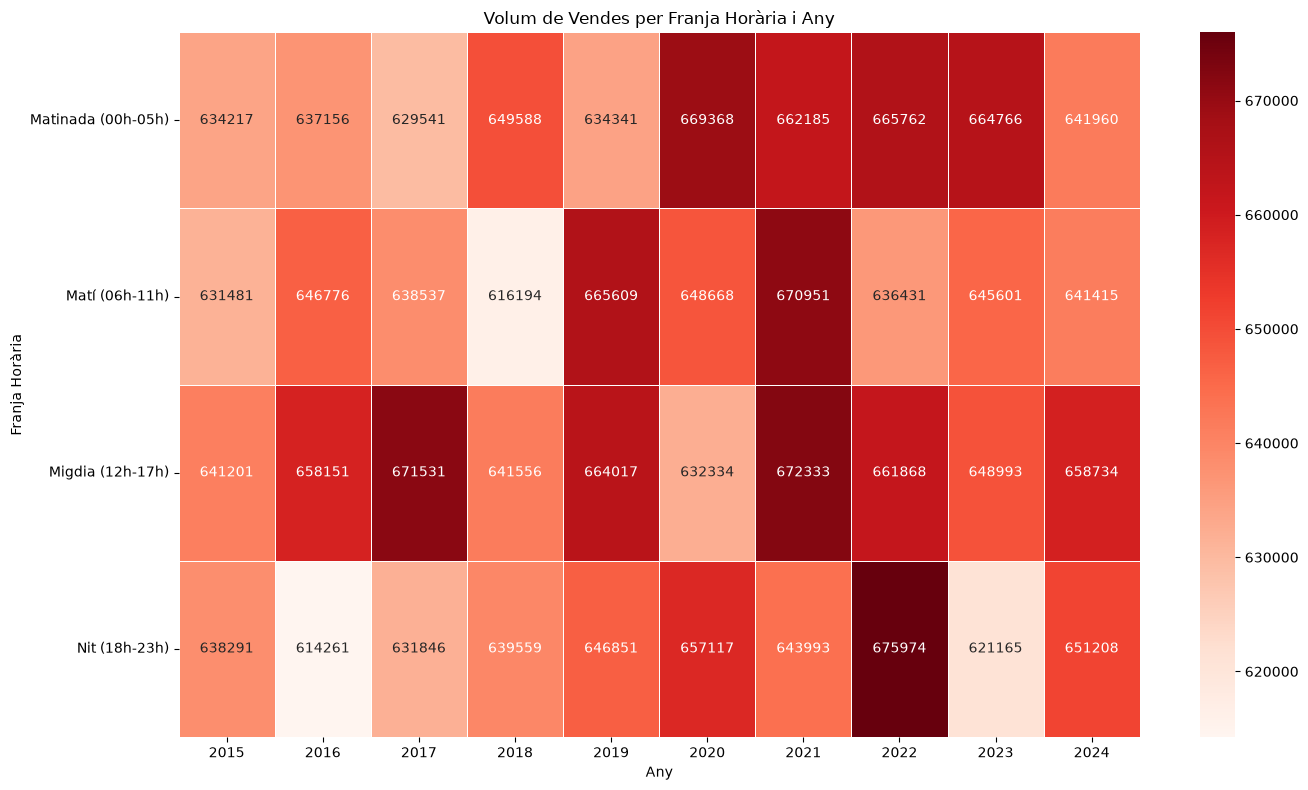

In [42]:
# Crear franges horàries a partir de l'hora
def franja_horaria(hora):
    if hora >= 0 and hora <= 5:
        return 'Matinada (00h-05h)'
    elif hora >= 6 and hora <= 11:
        return 'Matí (06h-11h)'
    elif hora >= 12 and hora <= 17:
        return 'Migdia (12h-17h)'
    else:
        return 'Nit (18h-23h)'

df_transaction['time_band'] = df_transaction['timestamp'].dt.hour.apply(franja_horaria)

# Assegurar que 'year' existeix
if 'year' not in df_transaction.columns:
    df_transaction['year'] = df_transaction['timestamp'].dt.year

# Construir una taula agregada utilitzant pivot_table
# Utilitzarem la suma de 'amount' com a activitat de venda.
sales_activity_pivot = df_transaction.pivot_table(
    values='amount',
    index='time_band',
    columns='year',
    aggfunc='sum'
)

# Reordenar l'índex per assegurar l'ordre correcte de les franges horàries
ordered_time_bands = ['Matinada (00h-05h)', 'Matí (06h-11h)', 'Migdia (12h-17h)', 'Nit (18h-23h)']
sales_activity_pivot = sales_activity_pivot.reindex(ordered_time_bands)

display(sales_activity_pivot.head())

# Visualitzar amb un mapa de calor
plt.figure(figsize=(14, 8))
sns.heatmap(sales_activity_pivot, cmap='Reds', fmt=".0f", linewidths=.5, annot=True)
plt.title('Volum de Vendes per Franja Horària i Any')
plt.xlabel('Any')
plt.ylabel('Franja Horària')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()